# DeepSeek-V3 and Mixture-of-Experts Code Generation

In [1]:
# Locate fix_notebook_dir.py whether the kernel started in this folder or in the
# repository root, then let it put pyncd on the import path. See fix_notebook_dir.py.
import sys; sys.path[:0] = ['.', 'example_notebooks']
import fix_notebook_dir

In [2]:
import construction_helpers as ch # Needed for @ auto-alignment
import data_structure.Category as cat
import data_structure.Numeric as nm
import data_structure.Operators as ops
import data_structure.Term as fd
import deepseek.data_structure as ds
import graphs.Hypergraph2Morphism as h2m
import websocket_transfer.capture as cap

In [3]:
## Helper functions to set up descriptive blocks and blocks that expand as we hover.
## h2m.recylce uses the graph code to reconstruct an expression in a standard format.
def standard_block(target: cat.BroadcastedCategory, color: str, short_name: str | None = None, title: str | None = None):
    title = title or short_name
    block = cat.Block(
            h2m.recycle(target),
            block_tag=cat.BlockTag(
                aesthetics=cat.BlockAesthetics(
                    title=title,
                    fill_color=color)))
    return block
def hover_block(target: cat.BroadcastedCategory, color: str, short_name: str | None = None, title: str | None = None):
    block = standard_block(target, color, short_name, title)
    block_operation = ops.BlockOperator.template(block, short_name)
    return block_operation

## Mixture of Expert Generation - with Sparse

Requesting render from server...
Received from server: {"msgType": "Connected"}


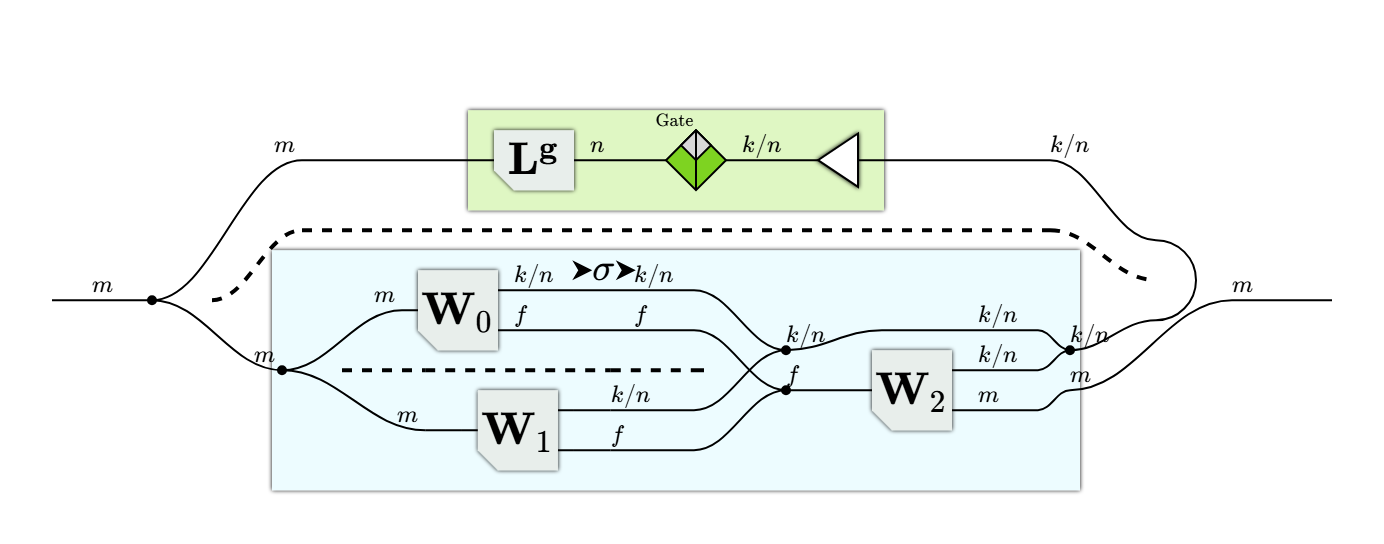

In [4]:
# The MoE on its own
gate = standard_block(
    ops.Linear.template('m', 1, 'L^g') @ ds.TopK.template() @ ops.SoftMax.template(),
    '#DFF7C3', 'Gate'
)

multihead_perceptron = standard_block(
    (0, 0) @
    ((ops.Linear.template(1, 2, 'W_0') @ ops.Elementwise.template())
     * ops.Linear.template(1, 2, 'W_1')) @
    ops.Einops.template('n f, n f -> n f') @
    ops.Linear.template(1, 2, 'W_2') @
    ops.Einops.template('k k m -> k m'),
    '#EDFCFF'
)

mixture_of_experts = (
    (0, 0) @
    (gate * multihead_perceptron) @ ops.Einops.template('n, n m -> m')
)
## Recycling reconstructs an expression from a block
await cap.capture_morphism(h2m.recycle(mixture_of_experts))

## Mixture of Expert Generation - Complete Form

Requesting render from server...
Received from server: {"msgType": "Connected"}


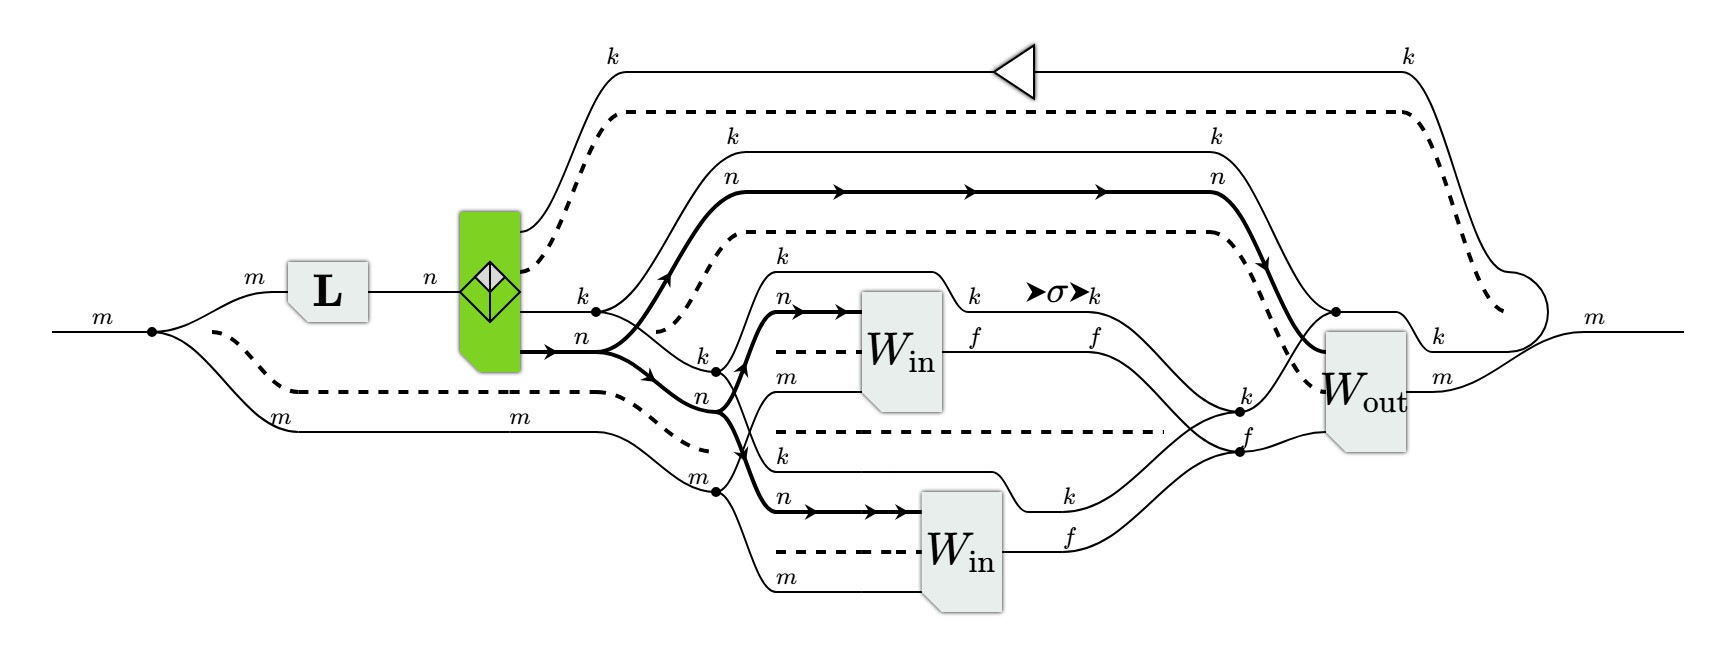

In [5]:
k_axis = fd.DynamicName('k').capture(cat.RawAxis())
m_axis = fd.DynamicName('m').capture(cat.RawAxis())
f_axis = fd.DynamicName('f').capture(cat.RawAxis())
n_numeric = fd.DynamicName('n').capture(nm.FreeNumeric())
n_count = cat.Natural(n_numeric)
n_axis = fd.DynamicName('n').capture(cat.RawAxis(_size=n_numeric))
input_weaves = (
    cat.Weave(n_count, (cat.WeaveMode.TILED,)),
    cat.Weave(cat.Reals(), (m_axis,)),
)
output_weaves = (
    cat.Weave(cat.Reals(), (cat.WeaveMode.TILED, f_axis)),
)
reindexings = (
    cat.Rearrangement((0,), (k_axis,)),
    cat.Rearrangement((), (k_axis,)),
)
W_in = cat.Broadcasted(
    operator=ops.Linear(fd.DynamicName('W', fd.DynamicName('\\text{in}'))),
    input_weaves=input_weaves,
    output_weaves=output_weaves,
    reindexings=reindexings
)
kn_array = W_in.dom()[0]
m_array = W_in.dom()[1]

W_out = cat.Broadcasted(
    operator=ops.Linear(fd.DynamicName('W', fd.DynamicName('\\text{out}'))),
    input_weaves=(
        cat.Weave(n_count, ()),
        cat.Weave(cat.Reals(), (f_axis,))
    ),
    output_weaves=(
        cat.Weave(cat.Reals(), (m_axis,)),
    ),
    reindexings=(
        cat.Rearrangement((), ()),
        cat.Rearrangement((), ())
    )
)

expert = (
    cat.Rearrangement(
        (0, 0, 1, 0, 1),
        (kn_array, m_array)
    ) @
    (kn_array * (((W_in @ ops.Elementwise.template()) * W_in) @ ops.Einops.template(',->'))) @
    W_out)

expert_gate = ops.Linear.template(1, n_axis) @ cat.Broadcasted(
    operator=ds.TopK(),
    input_weaves=(
        cat.Weave(cat.Reals(), (n_axis,)),
    ),
    output_weaves=(
        cat.Weave(cat.Reals(), (k_axis,)),
        cat.Weave(n_count, (k_axis,))
    ),
    reindexings=(
        cat.Rearrangement((), ()),
    )
) @ ops.SoftMax.template(contracted=True)

send_term = (
    (0, 0) @
    (expert_gate * cat.Array(cat.Reals(), (m_axis,))) @
    (cat.Array(cat.Reals(), (k_axis,)) * expert) @
    ops.Einops.template('k, k m -> m')
)

await cap.capture_morphism(h2m.recycle(send_term))

## DeepSeek-V3 - Full Generation

Requesting render from server...
Received from server: {"msgType": "Connected"}


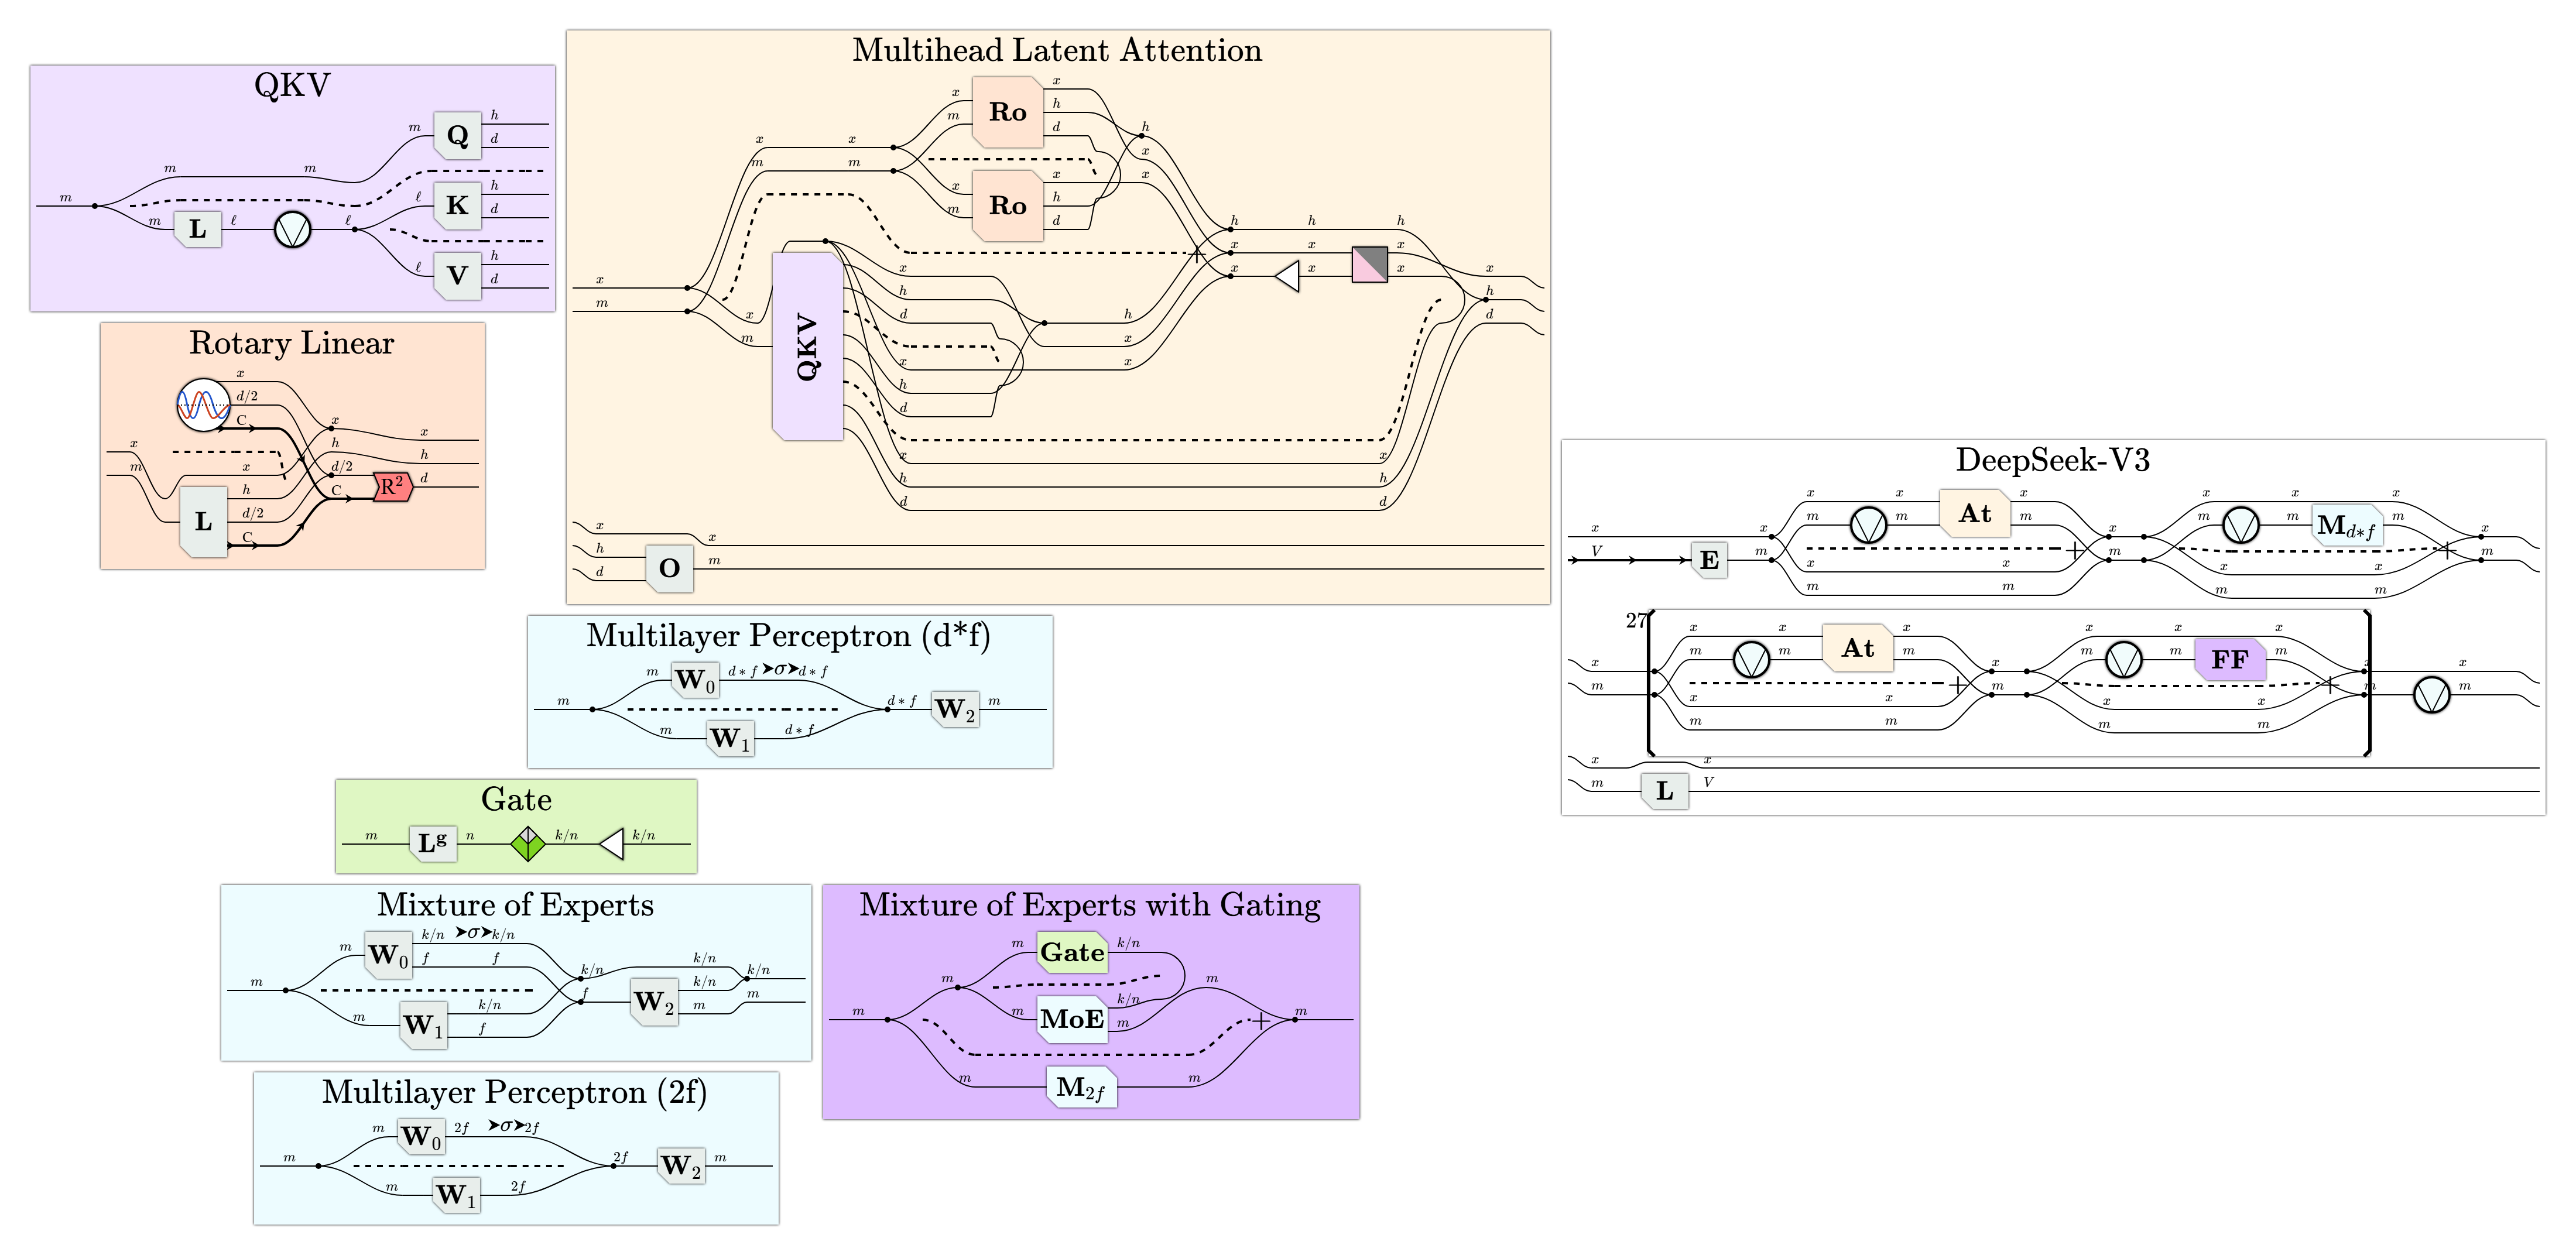

In [6]:
## SETUP MULTIHEAD LATENT ATTENTION with HOVER BLOCKS
rotary_linear = hover_block(
    (ds.ComplexRotary().template() 
     * (cat.RawAxis.named('x') >> ops.Linear.template(1, 2, output_datatype=ds.Complex()))) @
    ops.Einops.template('x d/2, x h d/2 -> x h d/2', datatype=ds.Complex()) @
    ds.Decomplex.template(), 
    '#FFE4D2', 'Ro', title='Rotary Linear' 
)

qk_matmul = ops.Einops.template('q h d, x h d -> h q x')

complex_s = (
    (0, 0) @
    (rotary_linear * rotary_linear) @
    qk_matmul
)

real_qkv = hover_block(
    (0, 0) @
      (ops.Linear.template(1, 2, 'Q')
    * (ops.Linear.template(1, '\\ell', 'L') @
       ops.Normalize.template() @
       (0, 0) @
       (ops.Linear.template(1, 2, 'K')
          * ops.Linear.template(1, 2, 'V')))),
    '#EFE1FF', 'QKV'
)

multihead_latent_attention = hover_block(
    (0, 0) @
    (complex_s * (real_qkv @ qk_matmul)) @
    ops.AdditionOp.template() @
    ops.SoftMax.template() @
    ops.WeightedTriangularLower.template() @
    ops.Einops.template('h q x, x h d -> q h d') @
    ops.Linear.template(2, 1, 'O'),
    '#FFF4E2', 'At', 'Multihead Latent Attention'
)

def multilayer_perceptron(inner_axis_name: str):
    return hover_block(
        (0, 0) @
        ((ops.Linear.template(name='W_0') @ ops.Elementwise.template())
            * ops.Linear.template(name='W_1')) @
        ops.Einops.template('2f, 2f -> 2f') @
        ops.Linear.template(inner_axis_name, name='W_2'),
        '#EDFCFF', f'M_{{{inner_axis_name}}}', title=f'Multilayer Perceptron ({inner_axis_name})'
    )

gate = hover_block(
    ops.Linear.template(1, 1, 'L^g') @ ds.TopK.template() @ ops.SoftMax.template(),
    '#DFF7C3', 'Gate'
)

multihead_perceptron = hover_block(
    (0, 0) @
    ((ops.Linear.template(1, 2, 'W_0') @ ops.Elementwise.template())
       * ops.Linear.template(1, 2, 'W_1')) @
    ops.Einops.template('n f, n f -> n f') @
    ops.Linear.template(1, 2, 'W_2') @
    ops.Einops.template('k k m -> k m'),
    '#EDFCFF', 'MoE', 'Mixture of Experts'
)

mixture_of_experts = hover_block(
    (0, 0) @
    (((0, 0) @ (gate * multihead_perceptron) @ ops.Einops.template('n, n m -> m'))
       * multilayer_perceptron('2f')) @
    ops.AdditionOp.template(),
    "#DDBBFF", 'FF', 'Mixture of Experts with Gating'
)

def resnet(target):
    return ((0, 0) @ ops.Normalize.template() @ target @ ops.AdditionOp.template())

deepseek_block = resnet(multihead_latent_attention) @ resnet(mixture_of_experts)

deepseek_model = standard_block(
    ops.Embedding.template('V', 1) @
    resnet(multihead_latent_attention) @
    resnet(multilayer_perceptron('d*f')) @
    cat.Block(
        body=deepseek_block,
        block_tag=cat.BlockTag(
            repetition=nm.Integer(27),
            aesthetics=cat.BlockAesthetics(fill_color='#FFFFFF')
        )
    ) @
    ops.Normalize.template() @
    ops.Linear.template(1, 'V'),
    '#FFFFFF', 'DeepSeek', 'DeepSeek-V3'
)

recycled_model = h2m.recycle(deepseek_model)
await cap.capture_morphism(recycled_model)

In [7]:
## We can generate a config for DeepSeek-V3, extracting the configurable degrees of freedom.
import term_utilities.generate_config as gc
import display.display_config as dpc

config = gc.NumericConfig.template(recycled_model)
print(dpc.display_config(config))

Name  |Type       |Bucket  |Assignment
V     |FreeNumeric|        |          
m     |FreeNumeric|        |          
x     |FreeNumeric|        |          
\ell  |FreeNumeric|        |          
h     |FreeNumeric|        |          
d     |FreeNumeric|        |          
d     |FreeNumeric|        |          
d/2   |FreeNumeric|        |          
d*f   |FreeNumeric|        |          
n     |FreeNumeric|        |          
k     |FreeNumeric|        |          
f     |FreeNumeric|        |          
2f    |FreeNumeric|        |          
V     |FreeNumeric|        |          


```
Name  |Type       |Bucket  |Assignment
V     |FreeNumeric|        |          
m     |FreeNumeric|        |          
x     |FreeNumeric|        |          
\ell  |FreeNumeric|        |          
h     |FreeNumeric|        |          
d     |FreeNumeric|        |          
d     |FreeNumeric|        |          
d/2   |FreeNumeric|        |          
d*f   |FreeNumeric|        |          
n     |FreeNumeric|        |          
k     |FreeNumeric|        |          
f     |FreeNumeric|        |          
2f    |FreeNumeric|        |          
V     |FreeNumeric|        |    
```